# 15. V5.1 Conservative Anchor–Challenger Pair Generator

Этот ноутбук проверяет исправленную версию V5. Главная проблема V5 была в том, что после `direction_locked` anchor–challenger продолжал обновлять `z_mean` слишком агрессивно и уводил систему после 14–15 шага.

В V5.1 anchor–challenger используется как **консервативный refinement / confirmation layer**:

- `anchor` = текущий лучший профиль, близкий к `state.z_mean`;
- `challenger` = локальная safe alternative по зоне;
- если выбран `anchor`, state почти не двигается;
- если выбран `challenger`, применяется маленький refinement-step;
- после `ready_to_finalize` обновления почти замораживаются.

In [2]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from personalization.batch_eval import win_rates_vs_baseline
from personalization.safe_anchor_challenger import V5_STRATEGY_NAME
from personalization.safe_anchor_challenger_v51 import (
    V51_DISPLAY_NAMES,
    V51_STRATEGY_NAME,
    run_v51_comparison_on_dataset,
    save_v51_outputs,
    source_usage_table_v51,
    summarize_v51_sessions,
)

use_article_style()


DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_MODE_DISPLAY_NAMES = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}
TARGET_MODE_ORDER = ['random8d', 'semantic4d', 'semantic6d', 'archetype8d']
STRATEGY_ORDER = ['semantic_active_v21', 'candidate_pool_active', V5_STRATEGY_NAME, V51_STRATEGY_NAME]

def sample_dataset(dataset, sample_per_mode=50, seed=42):
    if sample_per_mode is None or int(sample_per_mode) <= 0:
        return dataset.copy()
    sampled_parts = []
    for _, group in dataset.groupby('target_mode'):
        sampled_parts.append(group.sample(n=min(int(sample_per_mode), len(group)), random_state=seed))
    return pd.concat(sampled_parts, axis=0).reset_index(drop=True)

def add_display_columns(df):
    out = df.copy()
    out['target_mode_display'] = out['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(out['target_mode'])
    out['strategy_display'] = out['strategy'].map(V51_DISPLAY_NAMES).fillna(out['strategy'])
    return out

## Запуск batch-эксперимента

По умолчанию берём 50 пользователей на каждый режим. Для полного датасета поставь `SAMPLE_PER_MODE = None`.

In [3]:
SAMPLE_PER_MODE = 50
N_STEPS = 25

dataset = pd.read_csv(DATASET_PATH)
dataset_eval = sample_dataset(dataset, sample_per_mode=SAMPLE_PER_MODE)
print('Dataset rows used:', len(dataset_eval))

sessions, steps, curves = run_v51_comparison_on_dataset(
    dataset_eval,
    baseline_strategies=('semantic_active_v21', 'candidate_pool_active'),
    include_v5=True,
    n_steps=N_STEPS,
    step_scale=0.6,
    lr=0.25,
    clip_value=2.0,
)
summary = summarize_v51_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = source_usage_table_v51(steps)

save_v51_outputs(sessions, steps, summary, win_rates, source_usage, METRICS_DIR)
summary.to_csv(TABLE_DIR / 'article_v51_conservative_anchor_challenger_summary.csv', index=False)
win_rates.to_csv(TABLE_DIR / 'article_v51_conservative_anchor_challenger_win_rates.csv', index=False)
source_usage.to_csv(TABLE_DIR / 'article_v51_conservative_anchor_challenger_source_usage.csv', index=False)

summary

Dataset rows used: 200


,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,mean_direction_lock_step,mean_ready_step,ready_rate,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty,mean_applied_lr
3,archetype8d,semantic_active_v21,50,1.095608,0.364598,0.097147,0.262498,0.560286,58.324612,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,archetype8d,safe_anchor_challenger_v51,50,1.095608,0.416278,0.196952,0.369248,0.592078,56.778228,15.04,15.04,1.0,0.648465,0.658790,0.986018,0.018579,0.146672
0,archetype8d,candidate_pool_active,50,1.095608,0.477546,0.133387,0.324951,0.622914,43.057348,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,archetype8d,safe_anchor_challenger_v5,50,1.095608,0.595683,0.160116,0.310788,0.634502,26.683049,15.04,14.00,1.0,0.791940,0.860915,0.979673,0.061175,NaN
4,random8d,candidate_pool_active,50,2.121827,0.967592,0.445256,0.953201,1.502373,55.593227,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
5,random8d,safe_anchor_challenger_v5,50,2.121827,1.419877,0.511347,1.374041,1.664891,32.726517,15.02,14.00,1.0,0.785428,0.855019,0.981601,0.058163,NaN
7,random8d,semantic_active_v21,50,2.121827,1.450505,0.484755,1.412383,1.666669,30.716095,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
6,random8d,safe_anchor_challenger_v51,50,2.121827,1.550287,0.545518,1.536754,1.697723,27.240886,15.02,15.02,1.0,0.658494,0.717395,0.984927,0.020175,0.147868
11,semantic4d,semantic_active_v21,50,1.697778,0.431715,0.176675,0.332337,0.851257,70.982809,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
8,semantic4d,candidate_pool_active,50,1.697778,0.578102,0.218648,0.506176,0.943762,63.243664,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


## Mean final distance по режимам target

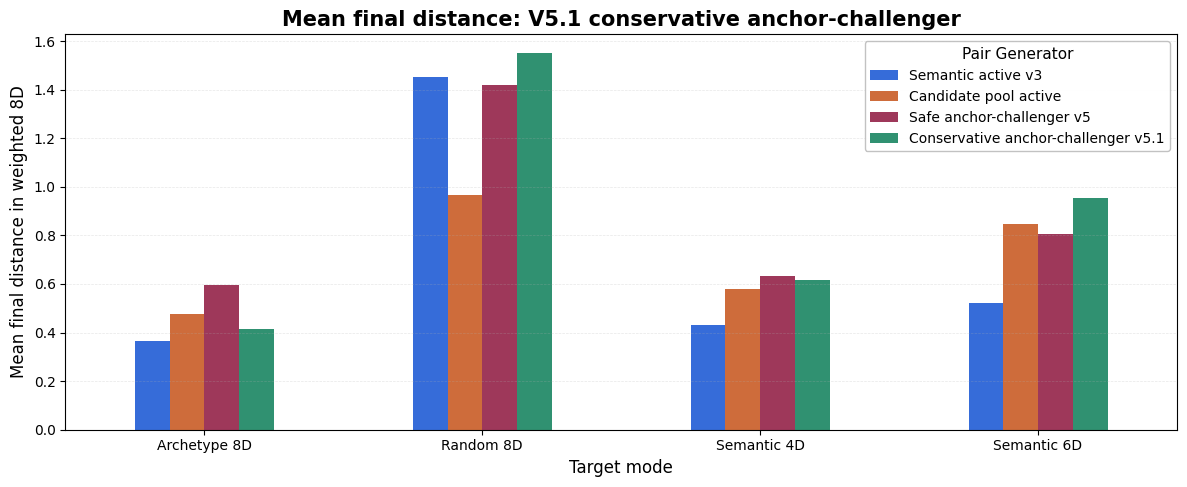

In [4]:
df = add_display_columns(summary)
df['target_mode'] = pd.Categorical(df['target_mode'], TARGET_MODE_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values(['target_mode', 'strategy'])
pivot = df.pivot(index='target_mode_display', columns='strategy_display', values='mean_final_distance')
cols = [V51_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if V51_DISPLAY_NAMES.get(s) in pivot.columns]
pivot = pivot[cols]

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean final distance: V5.1 conservative anchor-challenger', fontsize=15, fontweight='bold')
ax.set_xlabel('Target mode')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Pair Generator', frameon=True, facecolor='white', edgecolor='0.75')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v51_mean_final_distance_by_target.png', dpi=180, bbox_inches='tight')
plt.show()

## Сходимость на Archetype 8D

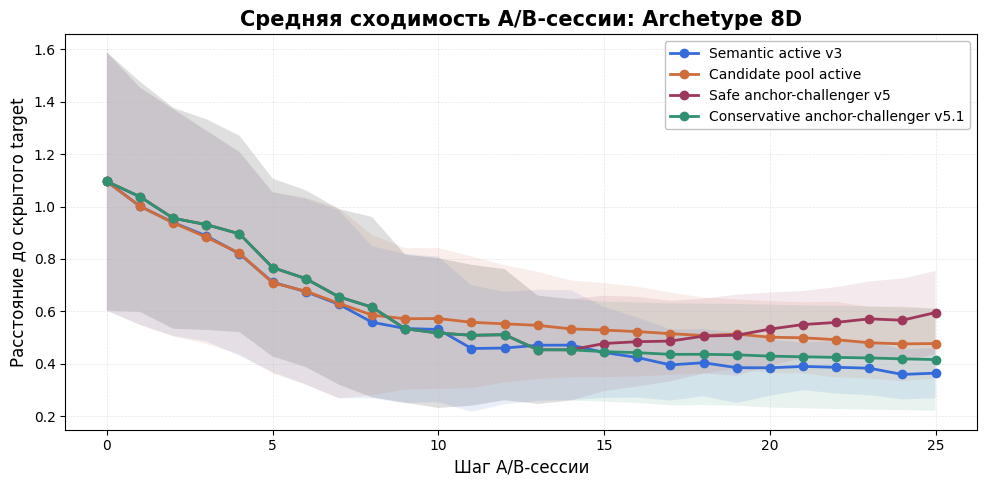

In [5]:
mode = 'archetype8d'
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
for strategy in STRATEGY_ORDER:
    arr = curves.get(mode, {}).get(strategy)
    if arr is None or len(arr) == 0:
        continue
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, marker='o', linewidth=2, label=V51_DISPLAY_NAMES.get(strategy, strategy))
    ax.fill_between(x, mean - std, mean + std, alpha=0.11)
ax.set_title('Средняя сходимость A/B-сессии: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Шаг A/B-сессии')
ax.set_ylabel('Расстояние до скрытого target')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v51_convergence_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()

## V5 vs V5.1 на Archetype 8D

Цель V5.1 — не обязательно обогнать `Semantic active v3`, а исправить overshoot старого V5 после включения anchor–challenger.

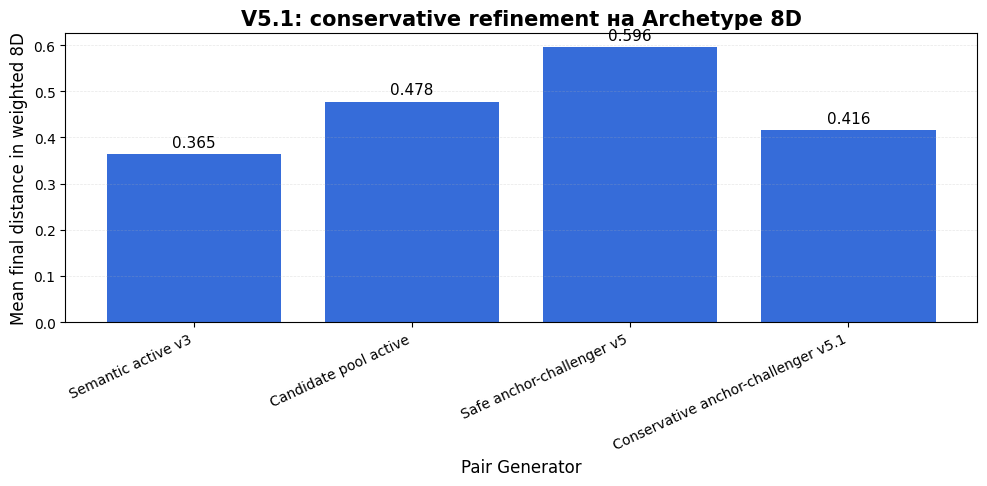

In [6]:
arch = add_display_columns(summary)
arch = arch[(arch['target_mode'] == 'archetype8d') & (arch['strategy'].isin(STRATEGY_ORDER))].copy()
arch['strategy'] = pd.Categorical(arch['strategy'], STRATEGY_ORDER, ordered=True)
arch = arch.sort_values('strategy')
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
bars = ax.bar(arch['strategy_display'], arch['mean_final_distance'])
ax.set_title('V5.1: conservative refinement на Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Pair Generator')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v51_archetype8d_final_distance.png', dpi=180, bbox_inches='tight')
plt.show()

## Диагностика качества A/B-пар и update после direction lock

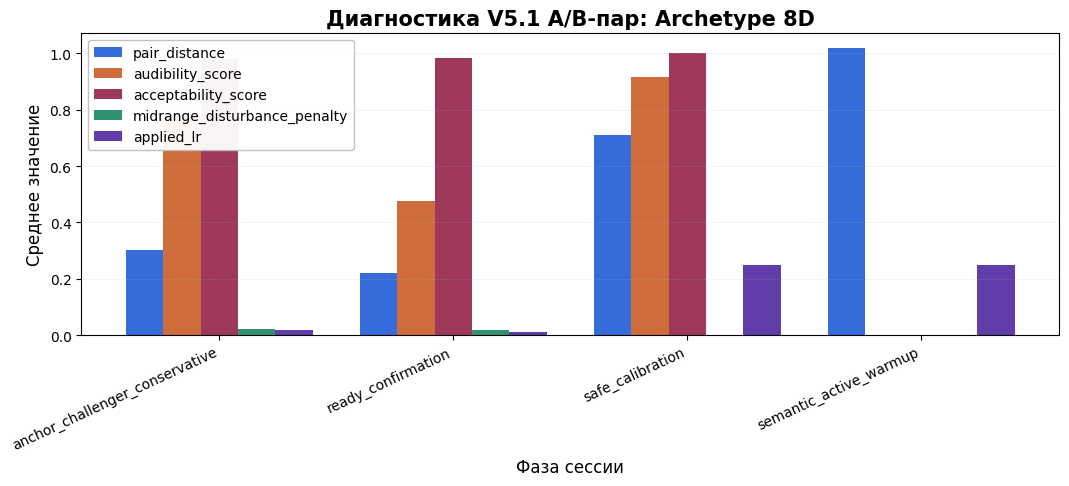

In [7]:
v51_steps = steps[(steps['target_mode'] == 'archetype8d') & (steps['strategy'] == V51_STRATEGY_NAME)].copy()
metrics = ['pair_distance', 'audibility_score', 'acceptability_score', 'midrange_disturbance_penalty', 'applied_lr']
grouped = v51_steps.groupby('phase')[metrics].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
x = np.arange(len(grouped))
width = 0.16
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 2) * width, grouped[metric], width=width, label=metric)
ax.set_title('Диагностика V5.1 A/B-пар: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Фаза сессии')
ax.set_ylabel('Среднее значение')
ax.set_xticks(x)
ax.set_xticklabels(grouped['phase'], rotation=25, ha='right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v51_pair_quality_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()

## Источники вопросов V5.1

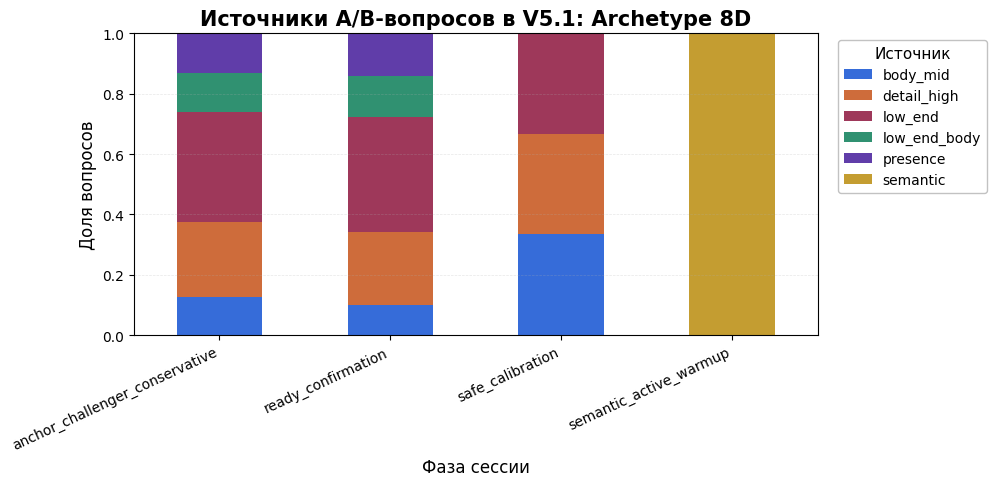

In [8]:
src = source_usage[(source_usage['target_mode'] == 'archetype8d') & (source_usage['strategy'] == V51_STRATEGY_NAME)].copy()
if not src.empty:
    pivot_src = src.pivot_table(index='phase', columns='pair_source_group', values='share', aggfunc='sum').fillna(0.0)
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
    pivot_src.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('Источники A/B-вопросов в V5.1: Archetype 8D', fontsize=15, fontweight='bold')
    ax.set_xlabel('Фаза сессии')
    ax.set_ylabel('Доля вопросов')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Источник', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'article_v51_pair_source_usage_archetype8d.png', dpi=180, bbox_inches='tight')
    plt.show()

идея anchor–challenger стала безопаснее, но она всё ещё ухудшает оптимизационную сходимость относительно чистого Semantic active v3.